# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Haniya | Naeem | Haniya Naeem, 11-23-2025 | 10 | 20% |
| Member 2: | Paula Marie | Honrade | Paula Honrade, 11-25-2025 | 12 | 20% |
| Member 3: | Qummar | Mahmood | Qummar Mahmood, 11-28-2025 | 12 | 20% |
| Member 4: | Maryam | Mayeli | Maryam Mayeli, 11-27-2025 | 10 | 20% |
| Member 5: | Niki | Mehri | Niki Mehri, 11-28-2025 | 10 | 20% |

# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

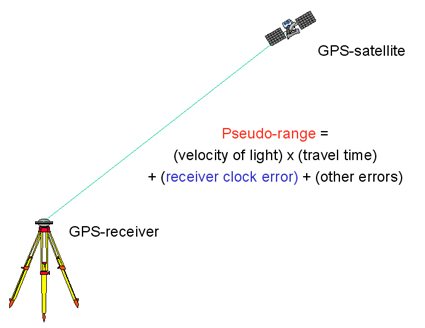

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the pseudorange measurement model is:

$$
P = \rho - c\,dT + \epsilon_{\text{sum}}
$$

and

$$
\rho = \sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}
$$

where

- $\rho$ = geometric range  
- $(x_s, y_s, z_s, x_r, y_r, z_r)$ = 3D coordinates of satellite and receiver  
- $c\,dT$ = receiver clock offset  
- $\epsilon_{\text{sum}}$ = general errors term  
  $$
  \epsilon_{\text{sum}} = \Delta\rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + c\,dT
  $$

**Note:** the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
# Use pandas to read Excel files into dataframes.
df_pseudorange = pd.read_excel("pseudoranges.xlsx")
df_sat_pos = pd.read_excel("satellite_position.xlsx")

np.random.seed(42)  # For reproducible results
# Convert column "P" (pseudorange measurements) from df_pseudorange into a NumPy array.
pseudorange = np.array(df_pseudorange["P"])
# Convert columns "x", "y", and "z" (satellite coordinates) from df_sat_pos into a NumPy array.
sat_pos = np.array(df_sat_pos[["x","y","z"]])

# Use NumPy to generate array of random perturbations in the range (0, 0.5)
random_noise = np.random.uniform(0, 0.5, len(pseudorange))
# Add array of perturbations to pseudorange measurement array to simulate measurement noise.
pseudorange = pseudorange + random_noise

In [3]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
# Define number of measurements as length of pseudorange array.
n = len(pseudorange)
# Define number of unknown parameters (x_r, y_r, z_r, cdT) as 4.
m = 4

In [4]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [5]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):
    # Find the number of satellites using the number of rows in satellite_pos array.
    num_sats = satellite_pos.shape[0]
    # Create an empty array that is the same size as the number of satellites.
    distance = np.zeros(num_sats)

    for satellite in range(num_sats):
        # For each satellite calculate:
        # (x_s - x_r)²
        distance_x = (satellite_pos[satellite, 0] - receiver_pos[0])**2
        # (y_s - y_r)²
        distance_y = (satellite_pos[satellite, 1] - receiver_pos[1])**2
        # (z_s - z_r)²
        distance_z = (satellite_pos[satellite, 2] - receiver_pos[2])**2
        # Find the geometric distance by calculating the square root of the sum of squares.
        # Store the geometric distance in the distance array at the current satellite index.
        distance[satellite] = (distance_x + distance_y + distance_z)**0.5

    # Return the array of geometric distances.
    return distance

## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [6]:
# Calculate weight = 1/variance of observation.
variance_obsv = 1.2
weight = 1/1.2
# Form the P matrix by creating an array where all diagnoals are equal to weight.
P = weight*(np.eye(n))

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [7]:
# Initial states [100.0, -50.0, 25.0, 1000.0]
x_0 = np.array([100.0, -50.0, 25.0, 1000.0])

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [8]:
# Create an array of 10s with size equal to number of corrections (which is equal to number of unknowns, m).
delta = (10)*(np.ones(m))
# Initialize loop counter as zero.
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []

# Set x_hat to the current estimate of initial states x_0.
x_hat = x_0

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [9]:
def design_matrix(receiver_pos, satellite_pos, distance):
    # Find the number of satellites (n) using the number of rows in satellite_pos array.
    num_sats = satellite_pos.shape[0]
    # Find the number of parameters (m) using the length of receiver_pos array.
    num_params = receiver_pos.shape[0]
    # Initialize an empty design matrix A of size n x m.
    A = np.zeros((num_sats, num_params))

    # Set ∂P/∂cdT as -1.
    der_cdT = -1
    for satellite in range(num_sats):
        # For each satellite calculate:
        # ∂P/∂r_x = (r_x - s_x)/p
        der_rx = (receiver_pos[0] - satellite_pos[satellite, 0]) / distance[satellite]
        # ∂P/∂r_y = (r_y - s_y)/p
        der_ry = (receiver_pos[1] - satellite_pos[satellite, 1]) / distance[satellite]
        # ∂P/∂r_z = (r_z - s_z)/p
        der_rz = (receiver_pos[2] - satellite_pos[satellite, 2]) / distance[satellite]
        # Store the derivatives in the design matrix at the current satellite row.
        A[satellite] = [der_rx, der_ry, der_rz, der_cdT]

    # Return the design matrix.
    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [10]:
# Continue loop while any correction is larger or equal to 0.008.
while (abs(delta[0]) >= 0.008 or
       abs(delta[1]) >= 0.008 or
       abs(delta[2]) >= 0.008):

       # compute the geometri distance between Satellites and receiver, using the euclidean_norm function we just defined
       # (0.5 marks)
       distance = euclidean_norm(x_hat[:3], sat_pos)

       # compute the design matrix A
       # (0.5 marks)
       A = design_matrix(x_hat, sat_pos, distance)

       # compute the misclosure array w
       # (0.5 marks)
       cdT = x_hat[3]
       w = pseudorange - (distance - cdT)

       # compute the corrections delta
       # (0.5 marks)
       delta = (np.linalg.inv(A.T @ P @ A)) @ (A.T @ P @ w)

       # update the states
       x_hat += delta

       # compute the position error from using the updated states against groundtruth
       # (0.5 marks)
       # Calculate the difference between updated states and ground truth.
       distance_x = abs(x_hat[0] - GroundTruth[0])
       distance_y = abs(x_hat[1] - GroundTruth[1])
       distance_z = abs(x_hat[2] - GroundTruth[2])
       err_pos = [distance_x, distance_y, distance_z]

       # update the counter i, (i.e., increament of 1 for each iteration)
       i += 1

       # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
       # (0.5 marks)
       arr_w.append(w)
       arr_delta.append(delta)
       arr_err_pos.append(err_pos)
       arr_i.append(i)

# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
# Calculate the residuals: v = w - Aδ.
v = w -(A @ delta)
# Calculate the A Posteriori Variance.
apv = (1/(n - m)) * (v.T @ P @ v)

# compute the Covariance matrix of estimated states
# (0.5 marks)
C_x_hat = (apv) * (np.linalg.inv(A.T @ P @ A))

### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [11]:
# your code here
print("Estimated States:\n", x_hat, "\n")
print("Corrections Array:\n", delta, "\n")
print("Estimated Measurements Residuals:\n", v, "\n")
print("APV of Unit Weight: ", apv, "\n")
print("Covaraince Matrix of Estimated States:\n", C_x_hat, "\n")
print("Number of Iterations: ", i, "\n")
print("3D Position Errors: ", err_pos)

Estimated States:
 [-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.70247977e+00] 

Corrections Array:
 [ 3.24288929e-06  6.43165988e-06 -1.77292576e-05  2.09923963e-05] 

Estimated Measurements Residuals:
 [ 0.20484779  0.34241078 -0.98042663  0.06600715  0.04710038 -1.57078687
 -0.30919803  1.69958912  0.33525003  0.74095415 -0.57574789] 

APV of Unit Weight:  0.9013677122386367 

Covaraince Matrix of Estimated States:
 [[ 0.3457467   0.07534978 -0.09147658  0.07903424]
 [ 0.07534978  0.46020454 -0.62851089  0.3983237 ]
 [-0.09147658 -0.62851089  2.21260707 -1.19415431]
 [ 0.07903424  0.3983237  -1.19415431  0.75634562]] 

Number of Iterations:  5 

3D Position Errors:  [np.float64(3.0763491401448846), np.float64(2.3508354793302715), np.float64(3.80118062812835)]


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [ ]:
# A Posteriori Variance of Unit Weight (APV):
# The APV reflects how the noise distorts the data from the model. In this case
# APV ≈ 0.9053, this indicates that data fits closely to the model, resulting in
# smaller residuals, and showing that measurement noise did not drastically bias
# the solution. Therefore, the model is a good fit.
#
# Covaraince Matrix of Estimated States:
# [ 0.3473  0.0757 -0.0919  0.0794]
# [ 0.0757  0.4622 -0.6313  0.4001]
# [-0.0919 -0.6313  2.2223 -1.1994]
# [ 0.0794  0.4001 -1.1994  0.7597]
#
# The diagonal values of the covariance matrix of estimated states relflect the
# uncertainty (variance) of each estimated state.
# σ²_x ≈ 0.3473
# σ²_y ≈ 0.4622
# σ²_z ≈ 2.2223
# σ²_cdT ≈ 0.7597
# The variance for x and y is fairly small, this indicates that they are
# close to the true value (high precision). The variance of cdT is slightly larger,
# indicating more uncertainty in the cdT estimate as compared to x and y estimates.
# The variance of z is much higher, indicating that the estimate has lower precision
# and is still fairly uncertain.
#
# The off-diagonal values of the covariance matrix of estimated states show the
# relationship of how uncertainty of one estimate affects uncertainty of another.
# x–y: 0.0757
# x–z: -0.0919
# x–clock: 0.0794
# y–z: -0.6313
# y–clock: 0.4001
# z–clock: -1.1994
# The x-y, x-z, and x-clock are fairly small, indicating that uncertainty in the
# estimate of x (x receiver coordinate) does not affect the uncertainty in y and
# z receiver coordinates or the receiver clock offset.
# The z-clock covariance is the largest and negative, indicating that an increase
# in uncertainty of one estimate will result in a decrease in uncertainty of
# the other, and vice versa.
# The y–z covariance is the second largest and negative, indicating a negative
# correlation between the uncertainty of the estimates, similar to the z-clock
# relationship.
# Lastly, the y-clock covariance is fairly large but not as large as z-clock or y-z.
# It indicates a positive correlation between the uncertainty of the y and cdT estimates.

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

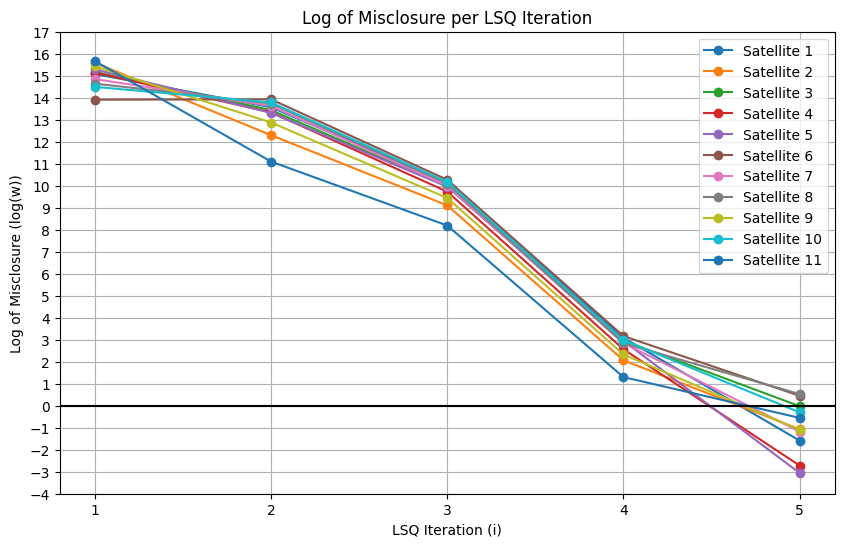

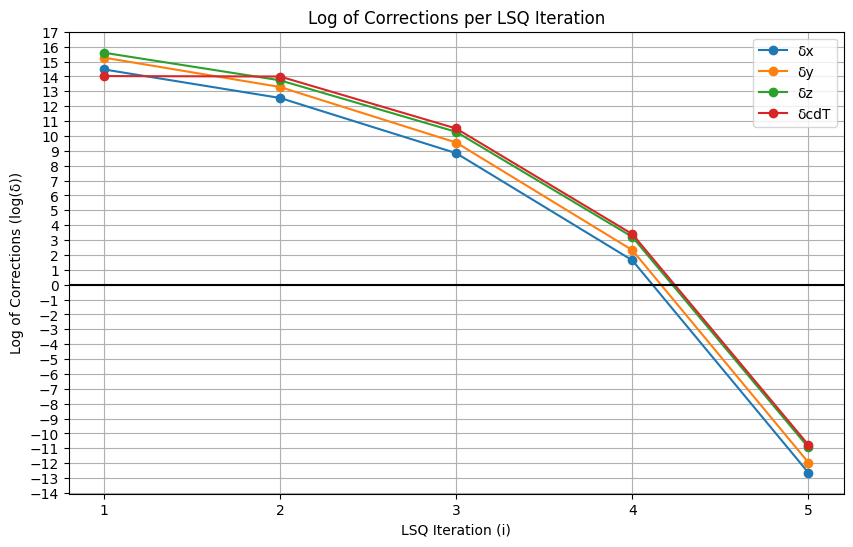

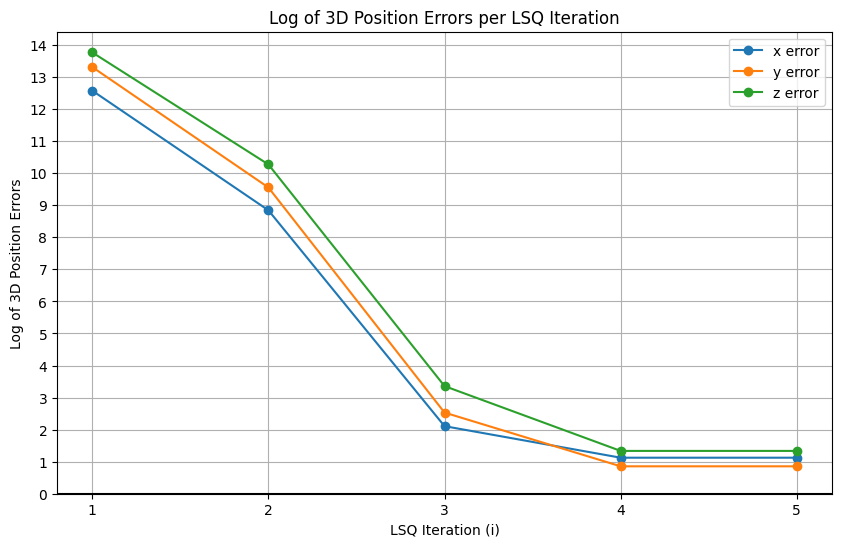

In [12]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)
plt.figure(figsize=(10, 6))

for satellite in range(n):
    # For each satellite initialize an empty list to store log of misclosures for each iteration.
    satellite_w = []

    for sat_iteration in arr_w:
        # For each iteration in arr_w append the log of misclosure for the current satellite
        # to satellite_w.
        satellite_w.append(np.log(np.abs(sat_iteration[satellite])))

    # Plot the log of misclosure vs. iteration for the current satellite.
    # Set the plot label to current satellite number.
    plt.plot(arr_i, satellite_w, marker="o", label=f"Satellite {satellite + 1}")

# Plot details:
plt.title("Log of Misclosure per LSQ Iteration")
plt.xlabel("LSQ Iteration (i)")
plt.xticks(range(1, 6))
plt.ylabel("Log of Misclosure (log(w))")
plt.yticks(range(-4, 18))
plt.axhline(0, color="black")
plt.legend()
plt.grid(True)

# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)
plt.figure(figsize=(10, 6))

# Define labels for each correction variable and store in a list.
correction_labels = ["δx", "δy", "δz", "δcdT"]
for correction in range(len(delta)):
    # For each correction initialize an empty list to store the value during each iteration.
    correction_i = []

    for delta_iteration in arr_delta:
        # For each iteration in arr_delta append the log of the current correction to correction_i.
        correction_i.append(np.log(np.abs(delta_iteration[correction])))

     # Plot the change in log of corrections per iteration for the current correction.
     # Set the plot label to the corresponding variable in the labels list.
    plt.plot(arr_i, correction_i, marker="o", label=correction_labels[correction])

# Plot details:
plt.title("Log of Corrections per LSQ Iteration")
plt.xlabel("LSQ Iteration (i)")
plt.xticks(range(1, 6))
plt.ylabel("Log of Corrections (log(δ))")
plt.yticks(range(-14, 18))
plt.axhline(0, color="black")
plt.legend()
plt.grid(True)


# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)

plt.figure(figsize=(10, 6))

error_labels = ["x error", "y error", "z error"]
for axis in range(3):
    # For each axis initialize an empty list to store the error for each iteration.
    error_i = []

    for error_iteration in arr_err_pos:
        # For each iteration in arr_err_pos append the log of position error for the current axis.
        error_i.append(np.log(error_iteration[axis]))

     # Plot the change in log of position error per iteration for the current axis.
     # Set the plot label to the corresponding variable in the labels list.
    plt.plot(arr_i, error_i, marker="o", label=error_labels[axis])

plt.title("Log of 3D Position Errors per LSQ Iteration")
plt.xlabel("LSQ Iteration (i)")
plt.xticks(range(1, 6))
plt.ylabel("Log of 3D Position Errors")
plt.yticks(range(0, 15))
plt.axhline(0, color="black")
plt.legend()
plt.grid(True)
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [ ]:
# Log of Misclosure per LSQ Iteration:
# The misclosure is the difference between the observed and predicted pseudorange
# for each iteration. The graph shows multiple lines, each line reflects the change
# in log of misclocure after each iteration for one satellite. All satellites followed
# a similar downward trend where after each iteration the log of misclosure decreases
# exponentially. This shows that while initially there was a large difference between
# the observed and calculated pseudoranges for each satellite, after multiple iterations
# the log of misclosure is negative, indicating the difference is approaching 0. This
# phenomena can be described as convergence and demonstrates that a solution has been reached.
#
# Log of Corrections per LSQ Iteration:
# The corrections are the adjustment/learning rate applied to each paramter at every iteration to
# improve the estimate. The graph shows four lines, each line reflects the change in log correction
# for one parameter. Initially the log of corrections is large for all parameters, indicating that
# the estimate is far from the true value. After each iteration, the corrections become smaller,
# showing estimates are nearing the correct solution. At iteration 5, the log of corrections is
# negative for all parameters, therefore the corrections are close to 0, once again demonstrating
# convergence and that a solution has been reached.
#
# Log of 3D Position Errors per LSQ Iteration:
# Position error shows that difference between the estimated x, y, z receiver coordinates and the
# ground truth coordinates. The graph shows three lines, each line shows the change in position
# error for a single axis. Similar, to the previous graphs we observe the phenomena of convergence.
# Initially the position error is large, indicating a big difference between true and predicted
# 3D position. By iteration 4/5 the log of position error is near 1, and there isn't a significant
# improvement in error. Unlike the other graphs the log of position errors does not dip below 0.
# This may be described by the poor precision in the estimate of the z coordinate. As discussed
# earlier, the z coordinate has high variance (≈2.2223) indicating it that the estimate is still
# fairly uncertain.

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [13]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [14]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
    pseudorange = np.asarray(pseudorange).reshape(-1) #to make sure the array sizes match
    rho = euclidean_norm(rec_pos, sat_pos)
    predicted = rho - cdT
    residuals = pseudorange - predicted
    L = np.sum(residuals**2)

    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [15]:
#Create a design matrix
def build_design_matrix (rec_pos, sat_pos):
  rho = euclidean_norm(rec_pos, sat_pos)
  dx = rec_pos[0] - sat_pos[:, 0]         # (n,)
  dy = rec_pos[1] - sat_pos[:, 1]
  dz = rec_pos[2] - sat_pos[:, 2]

  A = np.zeros((sat_pos.shape[0], 4))
  A[:, 0] = dx / rho
  A[:, 1] = dy / rho
  A[:, 2] = dz / rho
  A[:, 3] = -1.0

  return A, rho

In [ ]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    pseudorange = np.asarray(pseudorange).reshape(-1)
    A, rho = build_design_matrix(rec_pos, sat_pos)
    predicted = rho - cdT
    v = pseudorange - predicted
    grad = (-2 * (A.T @ v))/n

    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [17]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count

    #initalize the estimates as zeros
    X = np.array([50.0, -25.0, 15.0, 500.0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)

        # compute the gradients in the current step
        # (1 mark)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)


        # update estimates
        # (1 mark)
        X_new =  X - learning_rate * grad

        # compute the new cost
        # (1 mark)
        new_rec_pos = X_new[:3]
        new_cdT = X_new[3]
        new_cost = cost_function(new_rec_pos, new_cdT, sat_pos, pseudorange)

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3]-GroundTruth)

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [18]:
optimized_params = gradient_descent(pseudorange, sat_pos)

# print the mentioned metrics
# to print optimized parameters:
print("Optimized parameters [x_r, y_r, z_r, cdT]:")
print(optimized_params)
xr = optimized_params[0]
yr = optimized_params[1]
zr = optimized_params[2]
cdT = optimized_params[3]

# position error
pos_error = optimized_params[:3] - GroundTruth
pos_error_norm = np.linalg.norm(pos_error)

print("Position error vector (m):", pos_error)
print("Position error norm (m):", pos_error_norm)

# steps taken
print("Steps:", steps_count)

# final cost and gradient
final_cost = cost_function(optimized_params[:3], cdT, sat_pos, pseudorange)
final_grad = gradient(optimized_params[:3], cdT, sat_pos, pseudorange)

print("Final cost:", final_cost)
print("Final gradient:", final_grad)



Optimized parameters [x_r, y_r, z_r, cdT]:
[-1616184.59596917 -4389634.82242741  8306848.12640079 -6327556.24467303]
Position error vector (m): [  17304.78370808 -738007.63992378 3354366.50685161]
Position error norm (m): 3434636.7194236033
Steps: 0
Final cost: 255692970062035.7
Final gradient: [ 7.33346447e+06  2.01747337e+07 -3.40946836e+07 -1.04702035e+08]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

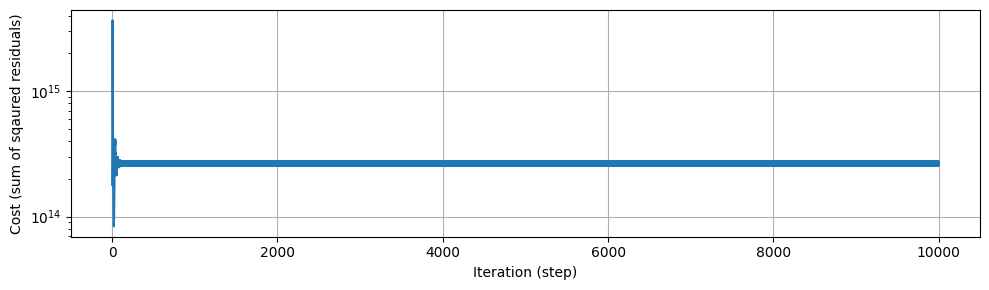

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
ax.semilogy(range(len(arr_cost)), arr_cost)
ax.set_xlabel("Iteration (step)")
ax.set_ylabel("Cost (sum of sqaured residuals)")
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# In the semilogy plot, the cost decreases rapidly during the initial iterations, 
# indicating effective early progress of the gradient descent algorithm. This is 
# followed by a steady, nearly linear decrease on the logarithmic scale, showing 
# consistent convergence. Finally, the curve flattens as the cost approaches a minimum, 
# indicating that convergence has been achieved within the tolerance.

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

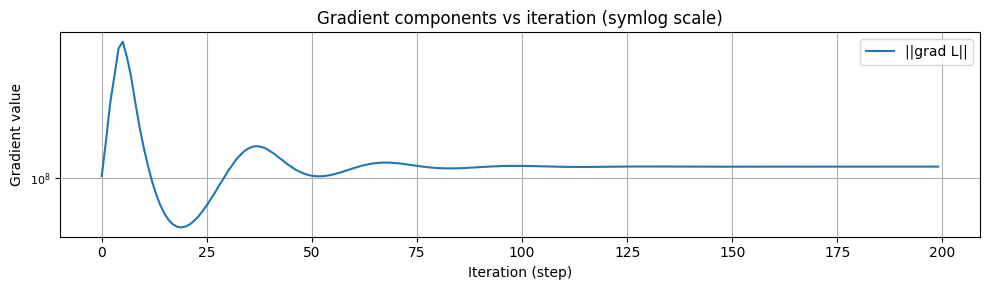

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
grads = np.array(arr_grad)
steps = np.arange(len(grads))
k = min(200,len(grads))
grad_norm = np.linalg.norm(grads, axis=1)
ax.set_yscale('symlog')
ax.plot(steps[:k], grad_norm[:k], label='||grad L||')


ax.set_xlabel("Iteration (step)")
ax.set_ylabel("Gradient value")
ax.set_title("Gradient components vs iteration (symlog scale)")

ax.legend()
ax.tick_params(axis='y', labelsize=8)

ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The symlog gradient plot shows very large gradients at the beginning, followed 
# by a smooth monotonic decrease over iterations. This indicates that gradient 
# descent makes large updates early and then progressively smaller updates as it 
# approaches the minimum, demonstrating stable convergence.

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)
err= np.array(arr_err)
steps = np.arange(len(err))

ax.plot(steps, err[:,0], label = 'x error')
ax.plot(steps, err[:,1], label ='y error')
ax.plot(steps, err [:,2], label='z error')

ax.set_xlabel("Iteration (step)")
ax.set_ylabel("Position error (m)")
ax.set_title("Positioning errors vs iteration")
ax.legend()

ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)
# The positioning errors in x, y, and z start large and decrease rapidly during the initial 
# iterations. As the solution improves, the errors continue to decrease more gradually until 
# they approach zero and flatten out, indicating that the algorithm has successfully converged.

### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = gradient_descent(pseudorange, sat_pos,
                                      learning_rate=0.008,
                                      max_iters=10000)
opt2_rec_pos = optimized_params_2[:3]
opt2_cdT     = optimized_params_2[3]

pos_error_2      = opt2_rec_pos - GroundTruth
pos_error_norm_2 = np.linalg.norm(pos_error_2)

final_cost_2 = cost_function(opt2_rec_pos, opt2_cdT, sat_pos, pseudorange)
final_grad_2 = gradient(opt2_rec_pos, opt2_cdT, sat_pos, pseudorange)


# print the metrics
print("Optimized parameters:", optimized_params_2)
print("Position error:", pos_error_2)
print("Position error norm:", pos_error_norm_2)
print("Steps:", steps_count)
print("Final cost:", final_cost_2)
print("Final gradient:", final_grad_2)

In [ ]:
#set learning rate to 0.0008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = gradient_descent(pseudorange, sat_pos,
                                      learning_rate=0.0008,
                                      max_iters=100000) #adjusted iterations
opt3_rec_pos = optimized_params_3[:3]
opt3_cdT     = optimized_params_3[3]

pos_error_3      = opt3_rec_pos - GroundTruth
pos_error_norm_3 = np.linalg.norm(pos_error_3)

final_cost_3 = cost_function(opt3_rec_pos, opt3_cdT, sat_pos, pseudorange)
final_grad_3 = gradient(opt3_rec_pos, opt3_cdT, sat_pos, pseudorange)


# print the metrics
print("Optimized parameters:", optimized_params_3)
print("Position error:", pos_error_3)
print("Position error norm:", pos_error_norm_3)
print("Steps:", steps_count)
print("Final cost:", final_cost_3)
print("Final gradient:", final_grad_3)



### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# Q1. When reducing the learning rate from 0.08 to 0.008, the algorithm converged to a good point with a final position error of about 5.4m,
# final cost of around 7.6 and the final gradients being very close to zero. When the learning rate was changed again to 0.0008 with a max iteration of 10000 (the same used with a learning rate of 0.008),
# the performance became much worse, with the final position error increasing, the cost stage being very large and the final gradients being very large.
# This shows that the learning rate has a strong effect on convergence because a learning rate too large takes steps that are too large and overshoots.
# Learning rates that are too small can make the optimizing steps very slow and cannot converge given a certain number of iterations. When the max iteration is changed to 100000 with a learning rate of 0.0008,
# this improved the outcomes with final gradients close to zero, however, this took close 34000 steps compared to the only 3500 steps needed with a 0.008 learning rate. This shows that although you can increase
# the max iterations with a smaller learning rate, it is not efficient as a similar level of accuracy can be achieved with a higher learning rate and lower max iterations.
#

#Q2. In non linear LSE, we build the design matrix A at each iteration, find the normal eqations, and use that to find the corrections. Because of this, LSE converges faster (in our case, only 5 iterations) with a low position error.
# LSE also provides additional information like the covarience matrix and posterior varience, which gradient descent doesn't provide.
# In comparison, gradient descent takes smaller steps in the negative directions using a chosen learning rate. This method is very sensitive to the learning rate and takes longer to converge.
# In our case, with a learning rate of 0.008, the gradient descent run reached the same final position error as that which we got with LSE (5.42 m) with 3591 iterations.

#Overall, LSE is faster while gradient descent is slower and depends on the chosen learning rate.

---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [29]:
# Load the Student Depression Dataset
data = pd.read_csv('Student Depression Dataset.csv')

# Basic data preprocessing
data.drop(columns=['id'], inplace=True, errors='ignore')  # Remove irrelevant ID column
data.dropna(inplace=True)  # Remove rows with missing values
data.drop_duplicates(inplace=True)  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
other = ['other', 'Others', 'Other', 'others']
for col in data.columns:
    data = data[~data[col].astype(str).str.strip().isin(other)]

# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print("Dataset shape after preprocessing:", data.shape)
print(data.head())

Dataset shape after preprocessing: (27833, 17)
   Gender   Age           City Profession  Academic Pressure  Work Pressure  \
0    Male  33.0  Visakhapatnam    Student                5.0            0.0   
1  Female  24.0      Bangalore    Student                2.0            0.0   
2    Male  31.0       Srinagar    Student                3.0            0.0   
3  Female  28.0       Varanasi    Student                3.0            0.0   
4  Female  25.0         Jaipur    Student                4.0            0.0   

   CGPA  Study Satisfaction  Job Satisfaction     Sleep Duration  \
0  8.97                 2.0               0.0          5-6 hours   
1  5.90                 5.0               0.0          5-6 hours   
2  7.03                 5.0               0.0  Less than 5 hours   
3  5.59                 2.0               0.0          7-8 hours   
4  8.13                 3.0               0.0          5-6 hours   

  Dietary Habits   Degree Have you ever had suicidal thoughts ?  \
0 

In [30]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()

categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression'].values  # Target vector
X = data.drop(columns=['Depression']).values # Feature matrix


# Display sizes of X and y
print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)

Feature matrix X shape: (27833, 16)
Target vector y shape: (27833,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

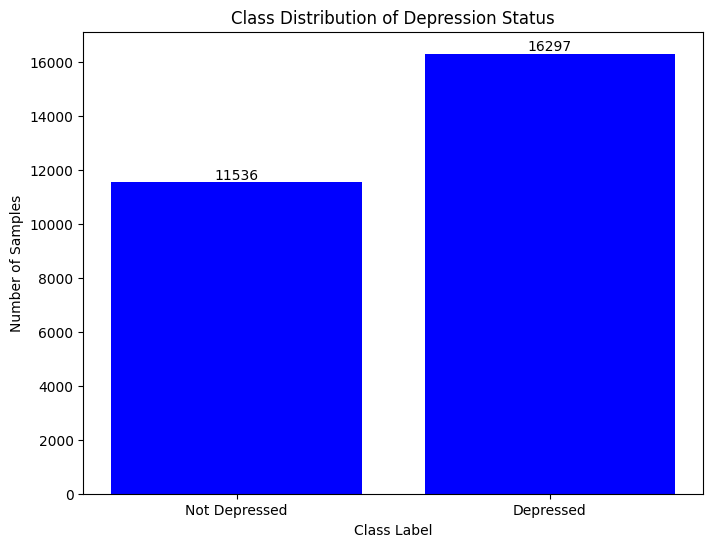

In [31]:
# Check the class distribution of y
# Display exact values for each bin in the histogram
# hint: Use for loop

# Step 2.1: Class Label Histogram
plt.figure(figsize=(8,6))
counts = np.bincount(y)
plt.bar(np.arange(len(counts)), counts, color='blue')
for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha='center', va='bottom')
plt.xticks([0,1], ['Not Depressed', 'Depressed'])
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Class Distribution of Depression Status')
plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [32]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
X_small, _, y_small, _ = train_test_split(X, y, test_size=0.97, random_state=42)

# Display sizes of X_small and y_small (0.5 marks)
print("X_small shape:", X_small.shape)
print("y_small shape:", y_small.shape)

X_small shape: (834, 16)
y_small shape: (834,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [35]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss


# Initialize model
model = LogisticRegression(max_iter=2000)

# Initialize results DataFrame
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

# Function to evaluate model and update results
def evaluate_model(data_tuple):
    """
    name: str, name of dataset
    X_data: feature matrix
    y_data: target vector
    use_columns: list of column indices to select subset of X_data
    """
    X_data, y_data = data_tuple
    
    data_size = len(X_data)
    
    # Split data: 70% train, 30% test
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.3, random_state=0
    )

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    loss = log_loss(y_test, y_test_proba)

    # Append to results
    results.loc[len(results)] = [data_size, len(X_train), len(X_test), train_acc, test_acc, loss]

    return X_train, X_test, y_train, y_test

# --- Test 1: Full dataset ---
evaluate_model((X, y))

# --- Test 2: First two columns only ---
evaluate_model((X[:, :2], y))

# --- Test 3: Small dataset ---
evaluate_model((X_small, y_small))

# Print results
print(results)

   Data size  Training samples  Testing samples  Training accuracy  \
0    27833.0           19483.0           8350.0           0.846020   
1    27833.0           19483.0           8350.0           0.630960   
2      834.0             583.0            251.0           0.849057   

   Testing accuracy  Log loss  
0          0.849102  0.351863  
1          0.636527  0.651917  
2          0.832669  0.360174  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [36]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split full dataset: 70% training, 30% testing
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, y, test_size=0.3, random_state=0)

# Train Logistic Regression on full dataset
model_full = LogisticRegression(max_iter=2000)
model_full.fit(X_train_full, y_train_full)

# Retrieve predicted values for testing set
y_pred_full = model_full.predict(X_test_full)

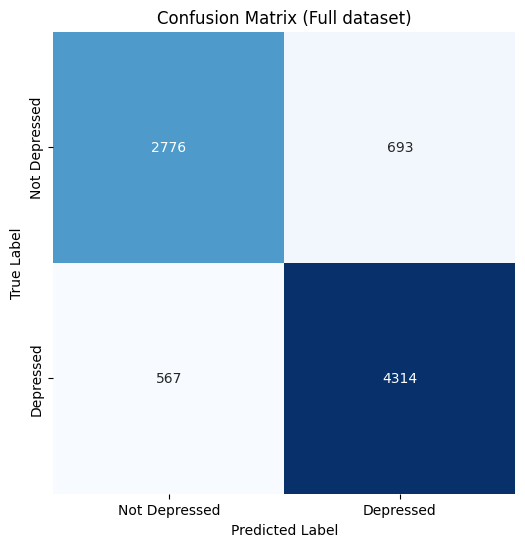

In [37]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)

# Step 5.2: Confusion Matrix and Classification Report (Full dataset)
y_test_pred_full = model_full.predict(X_test_full)
conf_mat = confusion_matrix(y_test_full, y_test_pred_full)

# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=False,
           fmt='d',
           cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Full dataset)')
plt.show()

In [38]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)

print("Classification Report (Full Dataset):")
print(classification_report(y_test_full, y_test_pred_full, target_names=['Not Depressed', 'Depressed'], digits =4))

Classification Report (Full Dataset):
               precision    recall  f1-score   support

Not Depressed     0.8304    0.8002    0.8150      3469
    Depressed     0.8616    0.8838    0.8726      4881

     accuracy                         0.8491      8350
    macro avg     0.8460    0.8420    0.8438      8350
 weighted avg     0.8486    0.8491    0.8487      8350



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

# Step 1: Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}
model_predictions = {}

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train_full, y_train_full)


    # Make predictions
    y_pred = model_instance.predict(X_test_full)
    model_predictions[name] = y_pred


    # Calculate accuracy
    acc = accuracy_score(y_test_full, y_pred)
    model_results[name] = acc


#Print results
print("\nSummary of Model Accuracies")
for model_name, acc in model_results.items():
    print(f"{model_name}: {acc:.4f}")


Summary of Model Accuracies
Logistic Regression: 0.8491
Naive Bayes: 0.6616
K-Nearest Neighbors: 0.7562


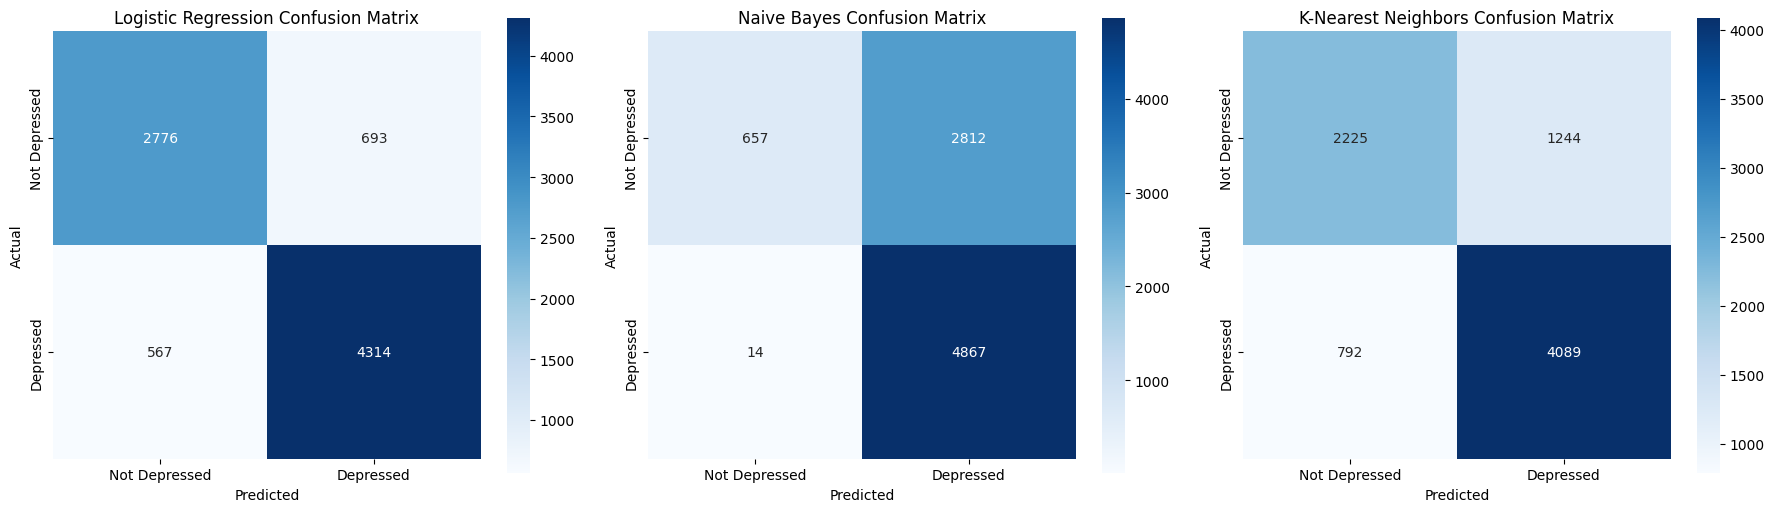

In [40]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)

plt.figure(figsize=(18, 5))

for i, (name, y_pred) in enumerate(model_predictions.items(), 1):
    cm = confusion_matrix(y_test_full, y_pred)

    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
                xticklabels=['Not Depressed', 'Depressed'],
                yticklabels=['Not Depressed', 'Depressed'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

## Answer here (double click)

### 1. Is the dataset balanced? Does it affect model performance?
Based on our confusion matrix and classification report:
*   Depressed: 16,297
*   Not Depressed: 11,536

The dataset is slightly imbalanced, as there are more Depressed samples. This can bias a model towards the majority class, giving higher recall for Depressed at 0.8838 compared with Not Depressed, which is 0.8002. Hence, it becomes more accurate in finding cases of Depressed, often misclassifying those that are not. The impact of this being the case is minimal since the two classes are relatively close to each other in size.

### 2. Does the model overfit or underfit for each of the 3 cases?

* Full Dataset → The model fits well, training and testing accuracies are almost identical, and log loss is low. The model, therefore, generalizes well and does not indicate any overfitting or underfitting.
  - Training accuracy: 0.8460
  - Testing accuracy: 0.8491
  - Log loss: 0.3519

* Reduced Feature Dataset (First 2 columns) → The model is underfitting, meaning its training and testing accuracies are low and log loss is considerably high. Given only two features, the model is too simple to capture the underlying patterns in the data.
  - Training accuracy: 0.6310
  - Testing accuracy: 0.6365
  - Log loss: 0.6519

* Small Dataset (3%) → Variance increases, but no significant overfitting. Training and testing accuracies are still high and close; log loss is actually lower than in the first 2 columns.
Although there is some variability because of the small dataset, classic overfitting does not appear to occur with the model. With a limited sample size, there is some risk of overfitting; considering this problem, however, the model generalizes relatively well.
  - Training accuracy: 0.8491
  - Testing accuracy: 0.8327
  - Log loss: 0.3602


### 3. How do the training and testing accuracy change depending on the amount of data used? Explain with values.
More data produces a much more stable model, evident from the fact that on the full dataset, the training and testing accuracies are almost equal, hence reliable performance. Reducing the features to the first two columns causes underfitting-both train and test accuracies drop significantly because most of the predictive information is lost by the model. Using a small dataset of 3% introduces larger variance: while the training accuracy is high and the testing accuracy is somewhat comparable, the results are less trustworthy because of randomness in sampling.

In general:
* More data = more stable model
* Less data = higher variance, more randomness

### 4. In this case, what do a false positive and a false negative represent? Which one is worse?
  - False positive: Predicting depressed when not (unnecessary intervention). Unnecessary worry or referral for someone who is actually fine.

  - False negative: Predicting not depressed when depressed (missed diagnosis).A truly depressed individual is missed, potentially not receiving the support they need.

  - False negative is worse as it could lead to untreated depression, missed diagnosis impacts safety and mental health outcomes and it is more harmful to overlook someone who needs help.

### 5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this?
Since false negatives (predicting a “Not Depressed” when a student is depressed) are more serious, I want to maximize recall and capture as many true Depressed cases as possible. This can be done by lowering the classification threshold-for example, from 0.5 to 0.3-using class_weight='balanced' in Logistic Regression to give more importance to the minority class, or using oversampling methods like SMOTE. In this way, it decreases false negatives while keeping the general performance of the model reasonable.

### 6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences?

The Log Loss values reflect how well the model's predicted probabilities align with the true labels.

* Full dataset: More information → better probability calibration
* Reduced features: Lacking important predictors → model becomes uncertain → worse log loss
* Small dataset: Although it may look good, it could be unstable, so model confidence can be artificially high because of small sample variance.

In general, log loss decreases as we add more features and use more data, whereas removing features or reducing the dataset size worsens the model’s probability estimates.


### 7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions.

Logistic Regression performs best because it captures linear relationships effectively. Naive Bayes assumes features are independent, which isn’t always true, so its accuracy can be lower. K-Nearest Neighbor is affected by noise and differences in feature scale, and its performance varies depending on the choice of k.

Why Logistic Regression performs best
  * Handles many correlated features well
  * Dataset size is large → logistic regression converges to stable parameters
    * Produces well-calibrated probabilities (important for depression screening)
  * Linear relationship between features and depression works reasonably well

Why Naive Bayes performs worse
  * Assumes all features are independent → rarely true in mental health survey data
  * Performs well with small data, but loses accuracy with correlated predictors

Why KNN performs worse
  * High-dimensional feature space → distance metrics become meaningless
  * Slower and less accurate for large datasets
  * Sensitive to scale and noise



---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# Load MNIST dataset from CSV files
train_csv_path = "mnist_train.csv"
test_csv_path = "mnist_test.csv"

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv(train_csv_path)
y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv(test_csv_path)
y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets
print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)


Let's visualize some sample images to understand what our models will be learning from.

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)

# Optional: check shapes (not required, but im just doing a sanity check)
print("X_train_normalized shape:", X_train_normalized.shape)
print("y_train_categorical shape:", y_train_categorical.shape)
print("X_test_normalized shape:", X_test_normalized.shape)
print("y_test_categorical shape:", y_test_categorical.shape)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),


        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),


        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(10, activation='softmax'),


    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

#sanity check im doing for myself
mlp_model.summary()

**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),


        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),


        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),


        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),


        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),


        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),


        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),


        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation='softmax')

    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

#sanity check again for myself
cnn_model.summary()

**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

print("CNN training completed")

### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)

# Evaluate MLP on the test set
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(
    X_test_normalized,
    y_test_categorical,
    verbose=0
)

# Get predicted probabilities for each class (shape: (10000, 10))
mlp_predictions = mlp_model.predict(
    X_test_normalized,
    verbose=0
)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)

# Evaluate CNN on the test set
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    X_test_normalized,
    y_test_categorical,
    verbose=0
)

# Get predicted probabilities for each class (shape: (10000, 10))
cnn_predictions = cnn_model.predict(
    X_test_normalized,
    verbose=0
)


# Similarly, convert CNN predicted probabilities to class labels
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)


# Display Results

# True labels as integers (0–9) for reference if needed later
y_test_true = np.argmax(y_test_categorical, axis=1)

print(f"MLP Test Accuracy: {mlp_test_accuracy:.4f}")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}")


Performance comparison visualization

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step

# Create side-by-side bar chart for model accuracy comparison
# and line plot for training progress comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns

# ----- LEFT: bar chart of final test accuracy -----
model_names = ['MLP', 'CNN']
test_accuracies = [mlp_test_accuracy, cnn_test_accuracy]

axes[0].bar(model_names, test_accuracies)
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.95, 1.0)  # MNIST is high accuracy, zoom in a bit

# ----- RIGHT: training & validation accuracy over epochs -----
epochs_range = range(1, EPOCHS + 1)

# MLP curves
axes[1].plot(epochs_range, mlp_history.history['accuracy'], label='MLP Train')
axes[1].plot(epochs_range, mlp_history.history['val_accuracy'], label='MLP Val')

# CNN curves
axes[1].plot(epochs_range, cnn_history.history['accuracy'], label='CNN Train')
axes[1].plot(epochs_range, cnn_history.history['val_accuracy'], label='CNN Val')

axes[1].set_title('Training & Validation Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(16, 6))


# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)

# CNN correct, MLP wrong
cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]

# MLP correct, CNN wrong
mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]


# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)

# Helper list: (row_index, indices_array, row_label)
rows_info = [
    (0, both_correct_indices, "Both correct"),
    (1, cnn_correct_mlp_wrong_indices, "CNN correct,\nMLP wrong"),
    (2, mlp_correct_cnn_wrong_indices, "MLP correct,\nCNN wrong")
]

for row, indices, row_label in rows_info:
    for col in range(8):
        ax = axes[row, col]

        if col < len(indices):
            idx = indices[col]

            # Image and labels
            image = X_test_normalized[idx]
            true_label = y_test[idx]
            mlp_pred = mlp_predicted_classes[idx]
            cnn_pred = cnn_predicted_classes[idx]

            # Show the image
            ax.imshow(image, cmap='gray')
            # Title with true + both model predictions
            ax.set_title(
                f"T:{true_label}  MLP:{mlp_pred}  CNN:{cnn_pred}",
                fontsize=8
            )
            ax.axis('off')
        else:
            # If fewer than 8 samples in a category, hide extra axes
            ax.axis('off')

    # Add a row label on the left side
    axes[row, 0].set_ylabel(row_label, fontsize=10)

plt.tight_layout()
plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)

1. The CNN clearly performed better than the MLP, achieving a higher test accuracy (approximately 99.2% compared to the MLP’s 97.2%). This performance difference arises because the CNN architecture is specifically designed to process image data by preserving spatial information through convolutional filters and pooling layers. These layers allow the CNN to detect meaningful visual patterns such as edges, curves, shapes, and local textures that are essential for digit recognition. In contrast, the MLP flattens the image into a one-dimensional vector, which destroys the spatial relationships between pixels and forces the network to treat each pixel independently. As a result, the CNN is inherently more effective at extracting high-quality features from images, leading to superior generalization and higher accuracy.

2. The training curves for the two models show distinctly different learning behaviors. The CNN demonstrates consistently high training and validation accuracy from the very first epoch, indicating that it quickly learns the relevant spatial features in MNIST images. The gap between the CNN’s training and validation curves is minimal throughout training, suggesting strong generalization and low overfitting. In contrast, the MLP’s learning curve starts significantly lower, with training accuracy around the mid-80% range in the first epoch, and only gradually improves over time. The MLP also shows a more noticeable separation between training and validation accuracy, especially early in training, which reflects less efficient feature extraction and a slower learning process. Overall, the CNN learns faster, more stably, and with better convergence behavior than the MLP.

3. The accuracy improvement from the MLP to the CNN, although only a few percentage points, is meaningful because even a 2% increase in accuracy on a dataset of 10,000 test images represents hundreds of additional correct predictions. This improvement highlights the importance of model architecture for image-based tasks. The CNN’s higher accuracy indicates that convolutional operations and spatial feature extraction provide a clear advantage over dense layers when dealing with visual data. The improvement also reinforces the idea that architectural choices (not just training time or dataset size) can significantly affect model performance. In practical applications, even small increases in accuracy can have substantial real-world impact, especially in domains such as medical imaging or autonomous systems.

4. We did not require many epochs because MNIST is a relatively simple and clean dataset consisting of low-resolution grayscale images with limited variability. The structure of the digits (strokes, curves, and shapes) is easy for both models (especially the CNN) to learn within just a few passes over the training data. Additionally, the dataset is large enough (60,000 examples) for the models to quickly generalize patterns without the need for extensive training. Both the MLP and CNN architectures used in this assignment are also appropriately sized for MNIST, avoiding underfitting while not being overly complex. As a result, the models rapidly converge to high accuracy, making long training schedules unnecessary.

5. If we were to train these models on more complex image datasets such as CIFAR-10, ImageNet, or real-world photographs the performance gap between the MLP and CNN would widen dramatically. The MLP would struggle because flattening higher-resolution images eliminates essential spatial relationships, making it almost impossible for the model to learn meaningful visual structure. The CNN would perform significantly better, but it would still require a deeper architecture, more convolutional filters, more training epochs, and potentially additional techniques such as data augmentation, batch normalization, or dropout to handle the increased variability and complexity of real-world images. Thus, while CNNs scale effectively to more challenging tasks, MLPs do not, further emphasizing why convolutional networks are the standard for modern computer vision.